# 01 - Data Exploration

Inspect the bundled seed data (historical international results, team metadata, and the 2026 group draw). The match results are real World Cup finals results from openfootball, spanning 1930-2026. A handful of 2026 debutant nations have no historical World Cup finals matches; the models fall back to league-average strengths for them (with a runtime warning). The printed list below shows exactly which teams that applies to for the currently vendored data.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)

from wcpredictor.data import load_matches, load_teams, load_groups
from wcpredictor.data.preprocess import build_training_matches, team_match_counts

In [2]:
matches = load_matches(config)
teams = load_teams(config)
groups = load_groups(config)
print('matches:', matches.shape)
print('teams:', teams.shape)
print('date range:', matches['date'].min().date(), '->', matches['date'].max().date())
matches.head()

matches: (1068, 7)
teams: (48, 3)
date range: 1930-07-13 -> 2026-07-19


,date,home_team,away_team,home_score,away_score,neutral,tournament
0,1930-07-13,France,Mexico,4,1,True,World Cup 1930
1,1930-07-13,USA,Belgium,3,0,True,World Cup 1930
2,1930-07-14,Yugoslavia,Brazil,2,1,True,World Cup 1930
3,1930-07-14,Romania,Peru,3,1,True,World Cup 1930
4,1930-07-15,Argentina,France,1,0,True,World Cup 1930


In [3]:
historical_teams = set(matches['home_team']) | set(matches['away_team'])
debutants = sorted(set(groups['team']) - historical_teams)
print('2026 teams with no historical World Cup finals data:', debutants)

2026 teams with no historical World Cup finals data: []


## Match outcomes (home / draw / away)

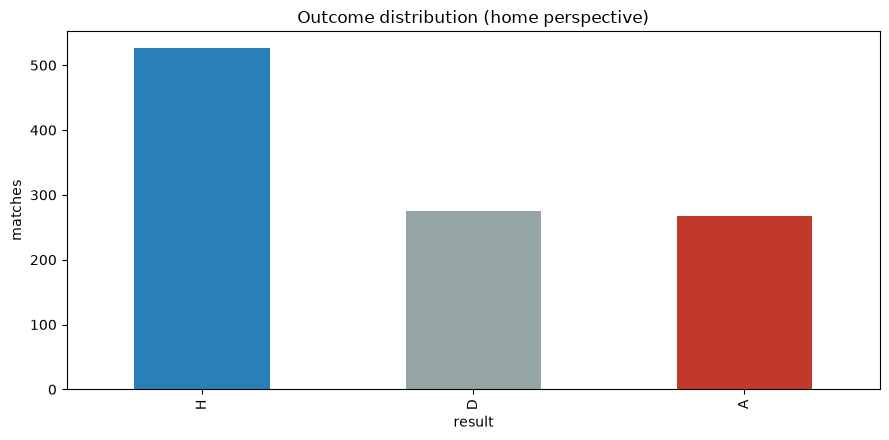

result
H    526
D    275
A    267
Name: count, dtype: int64

In [4]:
tr = build_training_matches(matches, config)
counts = tr['result'].value_counts().reindex(['H', 'D', 'A'])
ax = counts.plot.bar(color=['#2980b9', '#95a5a6', '#c0392b'])
ax.set_title('Outcome distribution (home perspective)')
ax.set_xlabel('result'); ax.set_ylabel('matches')
plt.tight_layout(); plt.show()
counts

## Goals per match

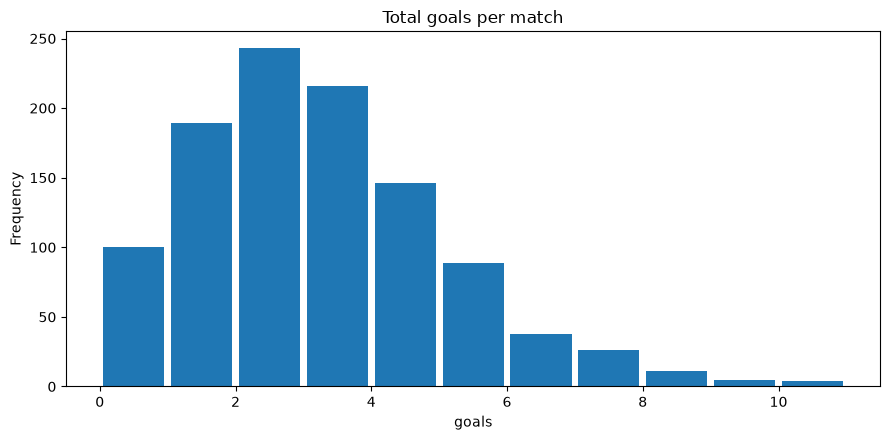

mean goals/match: 2.76


In [5]:
ax = tr['total_goals'].plot.hist(bins=range(0, 12), rwidth=0.9)
ax.set_title('Total goals per match')
ax.set_xlabel('goals'); plt.tight_layout(); plt.show()
print('mean goals/match:', round(tr['total_goals'].mean(), 2))

## Matches played per team and the group draw

In [6]:
display(team_match_counts(matches).head(10).to_frame('matches'))
groups.groupby('group')['team'].apply(list)

,matches
home_team,
Brazil,119
Germany,116
Argentina,96
Italy,83
England,82
France,81
Spain,75
Mexico,65
Uruguay,62


group
A    [Czech Republic, Mexico, South Africa, South K...
B    [Bosnia & Herzegovina, Canada, Qatar, Switzerl...
C                   [Brazil, Haiti, Morocco, Scotland]
D                   [Australia, Paraguay, Turkey, USA]
E             [Curaçao, Ecuador, Germany, Ivory Coast]
F                [Japan, Netherlands, Sweden, Tunisia]
G                  [Belgium, Egypt, Iran, New Zealand]
H           [Cape Verde, Saudi Arabia, Spain, Uruguay]
I                      [France, Iraq, Norway, Senegal]
J                [Algeria, Argentina, Austria, Jordan]
K           [Colombia, DR Congo, Portugal, Uzbekistan]
L                    [Croatia, England, Ghana, Panama]
Name: team, dtype: object